In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

n = 500
klienci = ["Anna Kowalska", "  Jan Nowak", "Anna Kowalska", "PIOTR WIŚNIEWSKI",
           "katarzyna lewandowska", "Tomasz Zieliński ", "Marta Wójcik",
           "anna kowalska ", "Krzysztof Kamiński", " Magdalena Dąbrowska"]
produkty = ["Laptop", "Mysz", "Klawiatura", "Monitor", "laptop", "MYSZ",
            "Słuchawki", "Pendrive", "monitor", "Webcam"]
kategorie = ["Elektronika", "elektronika", "ELEKTRONIKA", "Akcesoria",
             "akcesoria", "Akcesoria "]
miasta = ["Warszawa", "Kraków", "warszawa", "Gdańsk", "WROCŁAW",
          "Poznań", "Łódź ", " Warszawa", "kraków"]

start_date = datetime(2025, 1, 1)
daty_iso = [(start_date + timedelta(days=int(d))).strftime("%Y-%m-%d")
            for d in np.random.randint(0, 300, n // 2)]
daty_pl = [(start_date + timedelta(days=int(d))).strftime("%d.%m.%Y")
           for d in np.random.randint(0, 300, n // 2)]
daty = daty_iso + daty_pl
np.random.shuffle(daty)

df = pd.DataFrame({
    "order_id": range(1001, 1001 + n),
    "klient": np.random.choice(klienci, n),
    "produkt": np.random.choice(produkty, n),
    "kategoria": np.random.choice(kategorie, n),
    "miasto": np.random.choice(miasta, n),
    "ilosc": np.random.choice([1, 2, 3, 5, -1, 0], n, p=[0.5, 0.2, 0.15, 0.1, 0.025, 0.025]),
    "cena_jednostkowa": np.random.choice(
        ["199.99", "299,99", "1 499.00", "89.50", "2999", "399.00 zł", None, "abc"],
        n
    ),
    "data_zamowienia": daty,
    "email": np.random.choice(
        ["anna@gmail.com", "JAN@WP.PL", "piotr.w@onet", "marta@gmail.com",
         "tomasz@interia.pl", None, "krzysztof.k@gmail.com", "brak"],
        n
    )
})

# Wprowadzamy braki i duplikaty
for col in ["miasto", "kategoria", "data_zamowienia"]:
    df.loc[df.sample(frac=0.05, random_state=1).index, col] = np.nan

df = pd.concat([df, df.sample(20, random_state=2)], ignore_index=True)

df.to_csv("zamowienia_messy.csv", index=False)
print(f"Wygenerowano plik 'zamowienia_messy.csv' — {len(df)} wierszy")

Wygenerowano plik 'zamowienia_messy.csv' — 520 wierszy


In [6]:
df = pd.read_csv("zamowienia_messy.csv")
print("Kształt (shape):", df.shape)
df.head(10)
df.info()
df.describe(include="all")
df.isnull().sum()

Kształt (shape): (520, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_id          520 non-null    int64 
 1   klient            520 non-null    object
 2   produkt           520 non-null    object
 3   kategoria         495 non-null    object
 4   miasto            495 non-null    object
 5   ilosc             520 non-null    int64 
 6   cena_jednostkowa  457 non-null    object
 7   data_zamowienia   495 non-null    object
 8   email             457 non-null    object
dtypes: int64(2), object(7)
memory usage: 36.7+ KB


order_id             0
klient               0
produkt              0
kategoria           25
miasto              25
ilosc                0
cena_jednostkowa    63
data_zamowienia     25
email               63
dtype: int64

In [7]:
for col in ["klient", "produkt", "kategoria", "miasto", "cena_jednostkowa", "email"]:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))


=== klient ===
klient
Anna Kowalska            107
anna kowalska             58
Krzysztof Kamiński        56
katarzyna lewandowska     55
Marta Wójcik              55
 Magdalena Dąbrowska      54
  Jan Nowak               53
Tomasz Zieliński          45
PIOTR WIŚNIEWSKI          37
Name: count, dtype: int64

=== produkt ===
produkt
Mysz          62
MYSZ          56
Monitor       55
Laptop        53
Webcam        53
monitor       50
Słuchawki     49
Pendrive      49
laptop        48
Klawiatura    45
Name: count, dtype: int64

=== kategoria ===
kategoria
Akcesoria      90
akcesoria      90
elektronika    87
Akcesoria      82
Elektronika    80
ELEKTRONIKA    66
NaN            25
Name: count, dtype: int64

=== miasto ===
miasto
warszawa     61
kraków       60
Gdańsk       58
WROCŁAW      57
 Warszawa    57
Warszawa     54
Łódź         53
Poznań       53
Kraków       42
NaN          25
Name: count, dtype: int64

=== cena_jednostkowa ===
cena_jednostkowa
199.99       78
1 499.00     75
2999

In [ ]:
### Zidentyfikowane problemy z jakością danych
# 1. Niespójna wielkość liter - w kolumnach `klient`, `produkt`, `kategoria`, `miasto`, `email` te same wartości występują w różnych wariantach (np. `Anna Kowalska` / `anna kowalska`, `Mysz` / `MYSZ`). Zawyża liczbę unikalnych wartości.
# 2. Białe znaki - np. `" Jan Nowak"`, `"anna kowalska "`, `" Magdalena Dąbrowska"`, `"Akcesoria "`, `"Łódź "`, `" Warszawa"`. Te same wartości tekstowe traktowane są jako różne.
# 4. Niespójny format daty w `data_zamowienia` — część w ISO (`2025-04-09`), część w polskim (`13.06.2025`). Kolumna typu object zamiast datetime.
# 4. Nieprawidłowe wartości w `ilosc` - występują wartości ujemne (-1) i zero, które są nielogiczne dla ilości zamówienia.
# 5. Niespójność kategorii produktu - ten sam produkt (np. `Mysz`) bywa przypisany raz do `Elektronika`, raz do `Akcesoria`.

In [8]:
przed = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Usunięto {przed - len(df)} duplikatów. Pozostało {len(df)} wierszy.")

Usunięto 20 duplikatów. Pozostało 500 wierszy.


In [10]:
for col in ["klient", "produkt", "kategoria", "miasto"]:
    df[col] = df[col].astype("string").str.strip()

df["klient"] = df["klient"].str.title()
df["miasto"] = df["miasto"].str.title()
df["produkt"] = df["produkt"].str.capitalize()
df["kategoria"] = df["kategoria"].str.lower()

for col in ["klient", "produkt", "kategoria", "miasto"]:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))


=== klient ===
klient
Anna Kowalska            159
Magdalena Dąbrowska       53
Katarzyna Lewandowska     53
Marta Wójcik              52
Krzysztof Kamiński        52
Jan Nowak                 51
Tomasz Zieliński          43
Piotr Wiśniewski          37
Name: count, dtype: Int64

=== produkt ===
produkt
Mysz          114
Monitor       102
Laptop         98
Webcam         51
Pendrive       47
Słuchawki      45
Klawiatura     43
Name: count, dtype: Int64

=== kategoria ===
kategoria
akcesoria      256
elektronika    219
<NA>            25
Name: count, dtype: Int64

=== miasto ===
miasto
Warszawa    165
Kraków       98
Gdańsk       56
Wrocław      55
Poznań       53
Łódź         48
<NA>         25
Name: count, dtype: Int64


In [11]:
iso = pd.to_datetime(df["data_zamowienia"], format="%Y-%m-%d", errors="coerce")
pl  = pd.to_datetime(df["data_zamowienia"], format="%d.%m.%Y", errors="coerce")
df["data_zamowienia"] = iso.fillna(pl)

print("dtype:", df["data_zamowienia"].dtype)
print("Braki po konwersji:", df["data_zamowienia"].isna().sum())
print(df["data_zamowienia"].head())

dtype: datetime64[ns]
Braki po konwersji: 25
0   2025-06-13
1   2025-04-09
2   2025-01-04
3   2025-07-05
4   2025-02-05
Name: data_zamowienia, dtype: datetime64[ns]


In [12]:
df["cena_jednostkowa"] = (
    df["cena_jednostkowa"]
      .astype("string")
      .str.replace("zł", "", regex=False)
      .str.replace(" ", "", regex=False)
      .str.replace(",", ".", regex=False)
      .str.strip()
)
df["cena_jednostkowa"] = pd.to_numeric(df["cena_jednostkowa"], errors="coerce")

print("dtype:", df["cena_jednostkowa"].dtype)
print("Braki:", df["cena_jednostkowa"].isna().sum())
print(df["cena_jednostkowa"].describe())

dtype: Float64
Braki: 119
count          381.0
mean      924.930919
std      1031.591908
min             89.5
25%           199.99
50%            399.0
75%           1499.0
max           2999.0
Name: cena_jednostkowa, dtype: Float64


In [13]:
przed = len(df)
df = df.dropna(subset=["cena_jednostkowa", "data_zamowienia"]).reset_index(drop=True)
print(f"Usunięto {przed - len(df)} wierszy z brakami w cena/data.")

df["miasto"] = df["miasto"].fillna("unknown")
df["kategoria"] = df["kategoria"].fillna("unknown")
df["email"] = df["email"].fillna("brak_emaila")

print("\nBraki po obsłudze:")
print(df.isnull().sum())

Usunięto 138 wierszy z brakami w cena/data.

Braki po obsłudze:
order_id            0
klient              0
produkt             0
kategoria           0
miasto              0
ilosc               0
cena_jednostkowa    0
data_zamowienia     0
email               0
dtype: int64


In [14]:
przed = len(df)
df = df[df["ilosc"] > 0].reset_index(drop=True)
print(f"Usunięto {przed - len(df)} wierszy z ilosc <= 0. Pozostało {len(df)} wierszy.")

Usunięto 23 wierszy z ilosc <= 0. Pozostało 339 wierszy.


In [15]:
df["wartosc_zamowienia"] = df["ilosc"] * df["cena_jednostkowa"]

df["rok"] = df["data_zamowienia"].dt.year
df["miesiac"] = df["data_zamowienia"].dt.month
df["nazwa_dnia"] = df["data_zamowienia"].dt.day_name()

df["email_poprawny"] = df["email"].str.match(r"^[^@\s]+@[^@\s]+\.[^@\s]+$").fillna(False)

df[["ilosc", "cena_jednostkowa", "wartosc_zamowienia",
    "data_zamowienia", "rok", "miesiac", "nazwa_dnia",
    "email", "email_poprawny"]].head(10)

,ilosc,cena_jednostkowa,wartosc_zamowienia,data_zamowienia,rok,miesiac,nazwa_dnia,email,email_poprawny
0,2,199.99,399.98,2025-06-13,2025,6,Friday,brak_emaila,False
1,1,399.0,399.0,2025-04-09,2025,4,Wednesday,marta@gmail.com,True
2,1,1499.0,1499.0,2025-02-05,2025,2,Wednesday,anna@gmail.com,True
3,1,299.99,299.99,2025-07-04,2025,7,Friday,tomasz@interia.pl,True
4,1,1499.0,1499.0,2025-10-11,2025,10,Saturday,marta@gmail.com,True
5,3,199.99,599.97,2025-05-24,2025,5,Saturday,anna@gmail.com,True
6,1,199.99,199.99,2025-05-10,2025,5,Saturday,tomasz@interia.pl,True
7,1,2999.0,2999.0,2025-09-28,2025,9,Sunday,marta@gmail.com,True
8,2,199.99,399.98,2025-05-23,2025,5,Friday,anna@gmail.com,True
9,2,1499.0,2998.0,2025-06-29,2025,6,Sunday,anna@gmail.com,True


In [17]:
miesiecznie = (
    df.groupby(["rok", "miesiac"])["wartosc_zamowienia"]
      .sum()
      .round(2)
      .reset_index()
      .sort_values(["rok", "miesiac"])
)
miesiecznie

,rok,miesiac,wartosc_zamowienia
0,2025,1,37455.81
1,2025,2,76368.24
2,2025,3,66899.9
3,2025,4,75426.25
4,2025,5,39159.21
5,2025,6,65508.21
6,2025,7,29248.24
7,2025,8,59905.68
8,2025,9,68743.34
9,2025,10,38875.8


In [18]:
top5_klienci = (
    df.groupby("klient")["wartosc_zamowienia"]
      .sum()
      .round(2)
      .sort_values(ascending=False)
      .head(5)
)
top5_klienci

klient
Anna Kowalska            203426.36
Krzysztof Kamiński        84677.82
Katarzyna Lewandowska     55083.04
Marta Wójcik              51070.25
Magdalena Dąbrowska       49000.33
Name: wartosc_zamowienia, dtype: Float64

In [19]:
srednia_kategoria = (
    df.groupby("kategoria")["wartosc_zamowienia"]
      .mean()
      .round(2)
      .sort_values(ascending=False)
)
srednia_kategoria

kategoria
akcesoria      1671.66
elektronika    1614.06
Name: wartosc_zamowienia, dtype: Float64

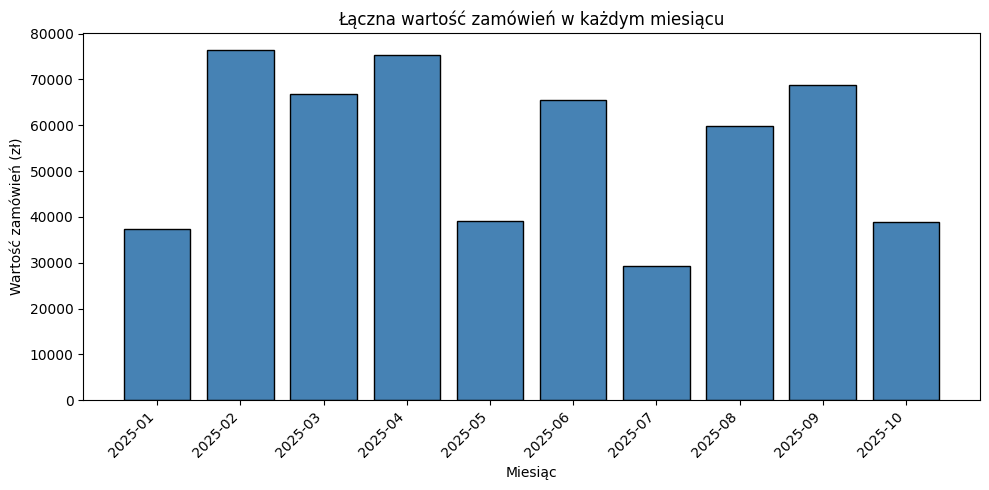

In [21]:
import matplotlib.pyplot as plt

miesiecznie = (
    df.groupby(["rok", "miesiac"])["wartosc_zamowienia"]
      .sum()
      .sort_index()
)
etykiety = [f"{r}-{m:02d}" for r, m in miesiecznie.index]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(etykiety, miesiecznie.values, color="steelblue", edgecolor="black")
ax.set_title("Łączna wartość zamówień w każdym miesiącu")
ax.set_xlabel("Miesiąc")
ax.set_ylabel("Wartość zamówień (zł)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [22]:
df.to_csv("zamowienia_clean.csv", index=False)
print(f"Zapisano 'zamowienia_clean.csv' — {len(df)} wierszy, {df.shape[1]} kolumn.")

Zapisano 'zamowienia_clean.csv' — 339 wierszy, 14 kolumn.
